<a href="https://colab.research.google.com/github/salikb7/Machine-Learning-on-Big-Data-/blob/main/Titanic_LogisticRegression_week4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Salik Ram Bhandari
#3260364
# Titanic Synthetic Dataset: Logistic Regression Classification (PySpark)

Adapted from the provided Diabetes-dataset PySpark Logistic Regression template. This notebook replaces the Diabetes
dataset with the Titanic synthetic dataset for binary classification (`Survived`), performs a class-imbalance check,
applies a class-weighting remedy, and follows the same feature engineering / modeling / evaluation pipeline.


In [14]:
# step 1 install pyspark using pip
!pip install pyspark

In [15]:
# step 2 create a spark session
from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .appName("Titanic Logistic Regression") \
    .config("spark.some.config.option", "some-value") \
    .getOrCreate()

spark


## Load the Dataset



In [16]:
# step 3 open the data file "titanic_synthetic_data.csv"
dataset = spark.read.csv("titanic_synthetic_data.csv", inferSchema=True, header=True)

# what are the columns in this dataset
dataset.columns


['Pclass',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Sex',
 'Survived',
 'Embarked_Q',
 'Embarked_S']

In [17]:
# use describe to see the data distribution
dataset.describe().select("Summary", "Pclass", "Age", "SibSp", "Parch").show()
dataset.describe().select("Summary", "Fare", "Sex", "Embarked_Q", "Embarked_S").show()


+-------+------------------+------------------+------------------+------------------+
|Summary|            Pclass|               Age|             SibSp|             Parch|
+-------+------------------+------------------+------------------+------------------+
|  count|           1000000|           1000000|           1000000|           1000000|
|   mean|          1.999411|         39.517847|          4.500906|          4.497493|
| stddev|0.8168263709530482|23.092708389398037|2.8714427426552285|2.8728101169393594|
|    min|                 1|                 0|                 0|                 0|
|    max|                 3|                79|                 9|                 9|
+-------+------------------+------------------+------------------+------------------+

+-------+------------------+------------------+-------------------+------------------+
|Summary|              Fare|               Sex|         Embarked_Q|        Embarked_S|
+-------+------------------+------------------+----

In [18]:
# check for Null / NaN values
from pyspark.sql.functions import col, isnan, when, count
dataset.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in dataset.columns]).show()


+------+---+-----+-----+----+---+--------+----------+----------+
|Pclass|Age|SibSp|Parch|Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+---+-----+-----+----+---+--------+----------+----------+
|     0|  0|    0|    0|   0|  0|       0|         0|         0|
+------+---+-----+-----+----+---+--------+----------+----------+



**No missing values.** Note: unlike the Diabetes dataset (where 0 was used as a sentinel for a missing reading in
`Glucose`/`BloodPressure`/`SkinThickness`/`BMI`/`Insulin`), there's no equivalent sentinel-missing-value problem here.
`Age` is uniformly distributed across its full 0-79 range (0 is a genuine newborn age, not a missing marker), `Fare`
has no zero values at all, and `Pclass`/`Sex`/`Embarked_Q`/`Embarked_S` are legitimate categorical codes where 0 is a
valid category. So no `Imputer` step is required for this dataset.

In [19]:
# combine all the features into a single feature vector
cols = dataset.columns
cols.remove("Survived")

from pyspark.ml.feature import VectorAssembler
assembler = VectorAssembler(inputCols=cols, outputCol="features")
dataset = assembler.transform(dataset)
dataset.select("features").show(truncate=False)


+-------------------------------------------------+
|features                                         |
+-------------------------------------------------+
|[3.0,42.0,6.0,7.0,397.00178367782024,0.0,0.0,1.0]|
|[1.0,52.0,6.0,7.0,302.12770032784186,0.0,1.0,0.0]|
|[3.0,25.0,3.0,8.0,427.1058765283985,1.0,1.0,0.0] |
|[3.0,32.0,9.0,7.0,326.8049924602327,1.0,0.0,0.0] |
|(8,[0,1,3,4],[1.0,40.0,5.0,17.718838497771657])  |
|[1.0,20.0,7.0,2.0,402.54904361394784,0.0,0.0,0.0]|
|[3.0,76.0,4.0,9.0,52.61038014285054,0.0,1.0,0.0] |
|[2.0,22.0,4.0,7.0,196.48213366632623,1.0,0.0,0.0]|
|[3.0,78.0,4.0,8.0,388.6259182464271,1.0,0.0,0.0] |
|[3.0,15.0,1.0,8.0,299.45900279822325,1.0,1.0,0.0]|
|[3.0,68.0,8.0,7.0,479.98134512112455,1.0,0.0,1.0]|
|[3.0,3.0,7.0,1.0,93.03405698775256,0.0,1.0,0.0]  |
|[1.0,63.0,4.0,0.0,84.64050143857706,1.0,0.0,0.0] |
|[3.0,0.0,9.0,8.0,296.7771124623517,0.0,0.0,1.0]  |
|[2.0,62.0,3.0,4.0,171.31211986091583,1.0,0.0,0.0]|
|[1.0,41.0,2.0,8.0,433.2922166813368,1.0,0.0,1.0] |
|[2.0,40.0,4

In [20]:
# Standard Scaler
from pyspark.ml.feature import StandardScaler
standardscaler = StandardScaler().setInputCol("features").setOutputCol("Scaled_features")
dataset = standardscaler.fit(dataset).transform(dataset)
dataset.select("features", "Scaled_features").show(5)


+--------------------+--------------------+
|            features|     Scaled_features|
+--------------------+--------------------+
|[3.0,42.0,6.0,7.0...|[3.67275115824148...|
|[1.0,52.0,6.0,7.0...|[1.22425038608049...|
|[3.0,25.0,3.0,8.0...|[3.67275115824148...|
|[3.0,32.0,9.0,7.0...|[3.67275115824148...|
|(8,[0,1,3,4],[1.0...|(8,[0,1,3,4],[1.2...|
+--------------------+--------------------+
only showing top 5 rows


In [21]:
# Train, test split
train, test = dataset.randomSplit([0.8, 0.2], seed=12345)


## Data Analysis: Check if the Dataset is Imbalanced

In [22]:
dataset_size = float(train.select("Survived").count())
numPositives = train.select("Survived").where('Survived == 1').count()
per_ones = (float(numPositives) / float(dataset_size)) * 100
numNegatives = float(dataset_size - numPositives)
print('The number of ones (Survived) are {}'.format(numPositives))
print('Percentage of ones are {}'.format(per_ones))

BalancingRatio = numNegatives / dataset_size
print('BalancingRatio = {}'.format(BalancingRatio))


The number of ones (Survived) are 399849
Percentage of ones are 49.965885404951486
BalancingRatio = 0.5003411459504851


## Apply the Imbalance Remedy: Class Weighting

The weighting code below runs regardless of how imbalanced the split turns out to be, so the same pipeline works
whether the dataset is skewed or close to even — check the printed percentage above to see which applies here.

In [23]:
from pyspark.sql.functions import when

train = train.withColumn("classWeights", when(train.Survived == 1, BalancingRatio).otherwise(1 - BalancingRatio))
train.select("classWeights").show(5)


+-------------------+
|       classWeights|
+-------------------+
|0.49965885404951493|
|0.49965885404951493|
| 0.5003411459504851|
| 0.5003411459504851|
| 0.5003411459504851|
+-------------------+
only showing top 5 rows


## Feature Selection using ChiSqSelector

`ChiSqSelector` runs a chi-square test, which requires categorical (discrete) features — Spark caps it at 10,000
distinct values per column. `Fare` is continuous with roughly 1,000,000 distinct values in this dataset, so
`ChiSqSelector` fails outright on the raw features. It only appeared to work in the Diabetes template because that
dataset has just 768 rows total, so even its continuous columns happened to stay under the 10,000-distinct-value
ceiling — not because `ChiSqSelector` was actually the right tool for continuous data. The fix: bucket the continuous
columns (`Age`, `Fare`) into discrete quantile bins before running the chi-square test.

In [24]:
from pyspark.ml.feature import QuantileDiscretizer, ChiSqSelector, VectorAssembler

age_bucketizer = QuantileDiscretizer(numBuckets=10, inputCol="Age", outputCol="AgeBucket")
fare_bucketizer = QuantileDiscretizer(numBuckets=10, inputCol="Fare", outputCol="FareBucket")
train = age_bucketizer.fit(train).transform(train)
train = fare_bucketizer.fit(train).transform(train)
test = age_bucketizer.fit(test).transform(test)
test = fare_bucketizer.fit(test).transform(test)

selection_assembler = VectorAssembler(
    inputCols=["Pclass", "AgeBucket", "SibSp", "Parch", "FareBucket", "Sex", "Embarked_Q", "Embarked_S"],
    outputCol="features_for_selection"
)
train = selection_assembler.transform(train)
test = selection_assembler.transform(test)

css = ChiSqSelector(featuresCol="features_for_selection", outputCol="Aspect", labelCol="Survived", fpr=0.05)
css_model = css.fit(train)
train = css_model.transform(train)
test = css_model.transform(test)
test.select("Aspect").show(5, truncate=False)

print("Selected feature indices (into [Pclass, AgeBucket, SibSp, Parch, FareBucket, Sex, Embarked_Q, Embarked_S]):",
      css_model.selectedFeatures)


+-------------------------------+
|Aspect                         |
+-------------------------------+
|(8,[0,4,5,6],[1.0,1.0,1.0,1.0])|
|(8,[0,3,4,6],[1.0,1.0,1.0,1.0])|
|(8,[0,3,4,7],[1.0,1.0,1.0,1.0])|
|(8,[0,3,4,5],[1.0,1.0,3.0,1.0])|
|(8,[0,3,4],[1.0,1.0,6.0])      |
+-------------------------------+
only showing top 5 rows
Selected feature indices (into [Pclass, AgeBucket, SibSp, Parch, FareBucket, Sex, Embarked_Q, Embarked_S]): [0, 1, 2, 3, 4, 5, 6, 7]


## Building a Classification Model using Logistic Regression

In [25]:
from pyspark.ml.classification import LogisticRegression
lr = LogisticRegression(labelCol="Survived", featuresCol="Aspect", weightCol="classWeights", maxIter=10)
model = lr.fit(train)
predict_train = model.transform(train)
predict_test = model.transform(test)
predict_test.select("Survived", "prediction").show(10)


+--------+----------+
|Survived|prediction|
+--------+----------+
|       0|       0.0|
|       0|       0.0|
|       1|       1.0|
|       1|       0.0|
|       1|       0.0|
|       0|       0.0|
|       0|       0.0|
|       1|       0.0|
|       1|       0.0|
|       1|       0.0|
+--------+----------+
only showing top 10 rows


## Evaluating the Model

In [26]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(rawPredictionCol="prediction", labelCol="Survived")
auroc = evaluator.evaluate(predict_test, {evaluator.metricName: "areaUnderROC"})

print("Area under ROC Curve: {:.4f}".format(auroc))

predict_test.select("Survived", "prediction", "probability").show(15)


Area under ROC Curve: 0.4971
+--------+----------+--------------------+
|Survived|prediction|         probability|
+--------+----------+--------------------+
|       0|       0.0|[0.50156180208066...|
|       0|       0.0|[0.50066199707847...|
|       1|       1.0|[0.49970303546477...|
|       1|       0.0|[0.50157495044787...|
|       1|       0.0|[0.50156168458968...|
|       0|       0.0|[0.50097724923789...|
|       0|       0.0|[0.50085162661079...|
|       1|       0.0|[0.50150171831152...|
|       1|       0.0|[0.50089075072153...|
|       1|       0.0|[0.50205936013437...|
|       1|       0.0|[0.50146842450549...|
|       1|       0.0|[0.50029304645587...|
|       0|       0.0|[0.50091716512048...|
|       0|       0.0|[0.50087072267263...|
|       1|       0.0|[0.50232816537386...|
+--------+----------+--------------------+
only showing top 15 rows


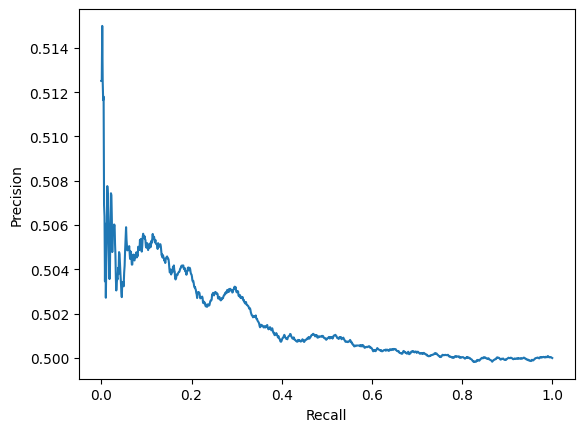

Model Accuracy 0.5008570334634501
FP rate [0.4994435399363285, 0.4988423931367722]
TP rate [0.5011576068632279, 0.5005564600636716]


In [27]:
print(model.summary)
import matplotlib.pyplot as plt
pr = model.summary.pr.toPandas()
plt.plot(pr["recall"], pr["precision"])
plt.ylabel("Precision")
plt.xlabel("Recall")
plt.show()
print("Model Accuracy", model.summary.accuracy)
print("FP rate", model.summary.falsePositiveRateByLabel)
print("TP rate", model.summary.truePositiveRateByLabel)


## Confusion Matrix

In [28]:
import numpy as np
pr = predict_test.toPandas()
TruePositive = 0
FalsePositive = 0
TrueNegative = 0
FalseNegative = 0
Postive = 1.0
Negative = 0.0
pos = 0
Neg = 0

print("Total", len(pr["Survived"]))
for lbl in range(len(pr["Survived"])):
    if pr["prediction"][lbl] == Postive:
        pos += 1
        if pr["prediction"][lbl] == pr["Survived"][lbl]:
            TruePositive += 1
        else:
            FalsePositive += 1
    if pr["prediction"][lbl] == Negative:
        Neg += 1
        if pr["prediction"][lbl] == pr["Survived"][lbl]:
            TrueNegative += 1
        else:
            FalseNegative += 1

print("TruePositive", TruePositive, "FalsePositive", FalsePositive)
print("TrueNegative", TrueNegative, "FalseNegative", FalseNegative)


Total 199756
TruePositive 49994 FalsePositive 50425
TrueNegative 49310 FalseNegative 50027


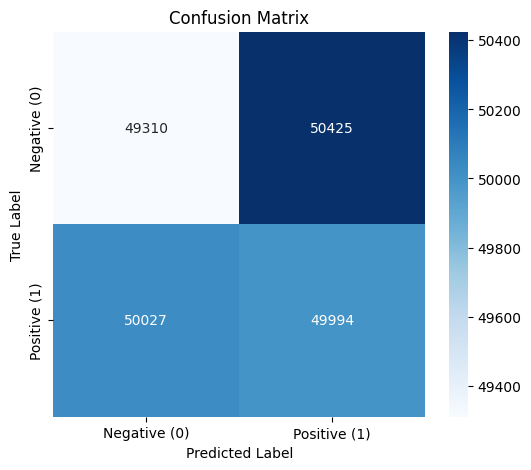

Precision: 0.4979
Recall:    0.4998
F1-score:  0.4988


In [29]:
import seaborn as sns
TN = TrueNegative
FP = FalsePositive
FN = FalseNegative
TP = TruePositive
conf_matrix = np.array([[TN, FP],
                        [FN, TP]])
labels = ["Negative (0)", "Positive (1)"]

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1_score:.4f}")


In [30]:
spark.stop()
